# Final Project — Customer Lifetime Value & Revenue Loss from Churn
## CS441V — Data Visualization (Spring 2026)

**Group 1 — Tan Tao University**
- Trieu Minh Thuan (2302059)
- Ho Nguyen Kim Long (2102161)

**Supervisor:** Nguyen Xuan Ha

---

## 📌 Project Focus

> **Core question: How much is each customer worth, who creates value, and how much money is the company losing to churn?**

Where the Midterm asked *"which characteristics relate to churn?"* and answered with simple distributions, this Final Project flips the question into a **financial lens**. We compute the dollar value each customer contributes (Customer Lifetime Value), identify who creates that value, quantify what churn destroys, and translate it into a Return-on-Investment case for retention spending.

The single problem is decomposed into **five research questions**:

1. **Q1.** How is Customer Lifetime Value distributed? Does the 80/20 rule hold here?
2. **Q2.** What does a top-20% "Gold" customer look like, vs a bottom-20% "Bronze" one?
3. **Q3.** How much revenue does churn actually destroy — past and future?
4. **Q4.** How does CLV grow with tenure (cohort analysis)?
5. **Q5.** What is the ROI of retention spending — at 10%, 20%, 30% save rates?

> **Note (VN)**: Notebook dùng comment tiếng Việt để dễ đọc; báo cáo Word viết bằng English.


## 1. Environment Setup

In [ ]:
# Thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

# Hiển thị
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.unicode_minus'] = False

# Tắt mathtext cho mọi text label/title — để dấu '\$' hiển thị literal
# (mặc định matplotlib parse '$...$' thành công thức toán → '\$97 vs \$46' bị lỗi font)
import matplotlib as _mpl
_orig_set_title = _mpl.axes.Axes.set_title
_orig_text      = _mpl.axes.Axes.text
_orig_annotate  = _mpl.axes.Axes.annotate
_orig_suptitle  = _mpl.figure.Figure.suptitle
_orig_xlabel    = _mpl.axes.Axes.set_xlabel
_orig_ylabel    = _mpl.axes.Axes.set_ylabel

def _patch(orig):
    def wrapper(*args, **kw):
        kw.setdefault('parse_math', False)
        return orig(*args, **kw)
    return wrapper

_mpl.axes.Axes.set_title    = _patch(_orig_set_title)
_mpl.axes.Axes.text         = _patch(_orig_text)
_mpl.axes.Axes.annotate     = _patch(_orig_annotate)
_mpl.figure.Figure.suptitle = _patch(_orig_suptitle)
_mpl.axes.Axes.set_xlabel   = _patch(_orig_xlabel)
_mpl.axes.Axes.set_ylabel   = _patch(_orig_ylabel)

sns.set_style('whitegrid')

# Bảng màu
COLOR_STAY  = '#2E86AB'
COLOR_CHURN = '#E63946'
COLOR_GOLD  = '#F4A261'
COLOR_TEAL  = '#2A9D8F'

print('Setup hoàn tất.')


Setup hoàn tất.


## 2. Data Loading & CLV Definition

### Why CLV instead of just Churn rate?

The Midterm Project showed that *"customers with low tenure churn more"*. True, but uninformative on its own — losing one long-tenured customer is far more damaging financially than losing one new customer. To compare those two cases fairly, we need a single dollar metric.

**Customer Lifetime Value (CLV)** is the standard metric. We split it into two parts:

- **CLV_realized** = `TotalCharges` already paid (past revenue, no longer at risk)
- **CLV_future** = expected remaining revenue over a 3-year (36-month) horizon
  - For churned customers: `0` (they already left)
  - For staying customers: `MonthlyCharges × max(0, 36 − tenure)`
- **CLV_lost** = the future revenue *would have been received* from churners — calculated as `MonthlyCharges × max(0, 36 − tenure)` if they were treated as still-active

This is a deliberately simple model — no discount rate, no cost-of-service. The goal is interpretability for stakeholders, not actuarial precision.


In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "mohankrishnathalla/predict-customer-churn-submission-dataset"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'predict-customer-churn-submission-dataset' dataset.
Dataset path: /kaggle/input/predict-customer-churn-submission-dataset


In [ ]:
import os

files = os.listdir(path)
print(files)

['V18.csv', 'V4.csv', 'V41.csv', 'V1.csv', 'V9.csv', 'V7.csv', 'V17.csv', 'V12.csv', 'V3.csv', 'V32.csv', 'V11.csv', 'V38.csv', 'V15.csv', 'V47.csv', 'V6.csv', 'V50.csv', 'V5.csv', 'V10.csv', 'V2.csv', 'Original.csv', 'V16.csv', 'V8.csv', 'V35.csv', 'V14.csv', 'V29.csv', 'V19.csv', 'V13.csv']


In [ ]:
# Load
df = pd.read_csv(f"{path}/Original.csv")
print(f'Shape: {df.shape}')

Shape: (7043, 21)


In [ ]:
# Tiền xử lý
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_bin']    = (df['Churn'] == 'Yes').astype(int)

# ---- Tính CLV ----
CLV_HORIZON = 36  # 3 năm

# Phần đã chi
df['CLV_realized'] = df['TotalCharges']

# Số tháng còn lại dự kiến (= 0 nếu đã churn)
df['Future_months'] = np.where(
    df['Churn_bin'] == 1, 0,
    np.maximum(0, CLV_HORIZON - df['tenure'])
)
df['CLV_future']   = df['Future_months'] * df['MonthlyCharges']
df['CLV_total']    = df['CLV_realized'] + df['CLV_future']

# Phần CLV đã mất do churn (chỉ có giá trị khác 0 cho khách đã rời bỏ)
df['CLV_lost'] = np.where(
    df['Churn_bin'] == 1,
    df['MonthlyCharges'] * np.maximum(0, CLV_HORIZON - df['tenure']),
    0
)

# Phân chia 5 quintile theo CLV_realized (giá trị đã chi)
df['CLV_quintile'] = pd.qcut(df['CLV_realized'], 5,
    labels=['Bronze', 'Q2', 'Q3', 'Q4', 'Gold'])

print('Đã tính xong CLV.')
df[['tenure','MonthlyCharges','TotalCharges','CLV_realized',
    'CLV_future','CLV_total','CLV_lost','CLV_quintile']].head()


Đã tính xong CLV.


,tenure,MonthlyCharges,TotalCharges,CLV_realized,CLV_future,CLV_total,CLV_lost,CLV_quintile
0,1,29.85,29.85,29.85,1044.75,1074.60,0.0,Bronze
1,34,56.95,1889.50,1889.50,113.90,2003.40,0.0,Q3
2,2,53.85,108.15,108.15,0.00,108.15,1830.9,Bronze
3,45,42.30,1840.75,1840.75,0.00,1840.75,0.0,Q3
4,2,70.70,151.65,151.65,0.00,151.65,2403.8,Bronze


In [ ]:
# Tổng quan tài chính
total_realized   = df['CLV_realized'].sum()
total_future     = df['CLV_future'].sum()
total_lost       = df['CLV_lost'].sum()
total_book       = total_realized + total_future + total_lost

# % future revenue bị mất do churn (tỉ lệ "tương lai mất")
pct_future_lost = total_lost / (total_lost + total_future)
# % của toàn book bị mất do churn
pct_book_lost   = total_lost / total_book

print(f"   TỔNG QUAN TÀI CHÍNH (3-year CLV horizon)")
print(f"   Doanh thu đã ghi nhận: ${total_realized:>13,.0f}")
print(f"   Doanh thu tương lai (khách còn ở): ${total_future:>13,.0f}")
print(f"   Doanh thu mất do churn: ${total_lost:>13,.0f}")
print(f"   ─────────────────────────────")
print(f"   Tổng book of business : ${total_book:>13,.0f}")
print(f"   % future revenue bị mất do churn:  {pct_future_lost:.1%}")
print(f"   % toàn book bị mất do churn:        {pct_book_lost:.1%}")


   TỔNG QUAN TÀI CHÍNH (3-year CLV horizon)
   Doanh thu đã ghi nhận: $   16,056,169
   Doanh thu tương lai (khách còn ở): $    2,535,388
   Doanh thu mất do churn: $    2,690,554
   ─────────────────────────────
   Tổng book of business : $   21,282,111
   % future revenue bị mất do churn:  51.5%
   % toàn book bị mất do churn:        12.6%


## 3. Q1 — How is CLV distributed? Does the 80/20 rule hold?

The first question for any value-based analysis is whether revenue is **concentrated** in a few customers (Pareto) or **spread evenly**. The answer determines whether to focus on a small number of high-value accounts, or to think in terms of broad mass-market retention.


In [ ]:
# Tính phân phối Pareto
sorted_clv = df['CLV_realized'].sort_values(ascending=False).reset_index(drop=True)
total_clv  = sorted_clv.sum()

# Cumulative share
cumulative_pct_customers = (np.arange(1, len(df)+1) / len(df)) * 100
cumulative_pct_revenue   = (sorted_clv.cumsum() / total_clv) * 100

# Mốc Pareto
pareto_points = []
for pct in [10, 20, 30, 50, 80]:
    idx = int(len(df) * pct / 100) - 1
    pareto_points.append({
        'Top % customers': pct,
        'n customers'    : idx + 1,
        '% of revenue'   : cumulative_pct_revenue.iloc[idx],
    })
pareto_df = pd.DataFrame(pareto_points)
print(pareto_df.round(1).to_string(index=False))


 Top % customers  n customers  % of revenue
              10          704          30.8
              20         1408          53.6
              30         2112          70.2
              50         3521          88.9
              80         5634          99.1


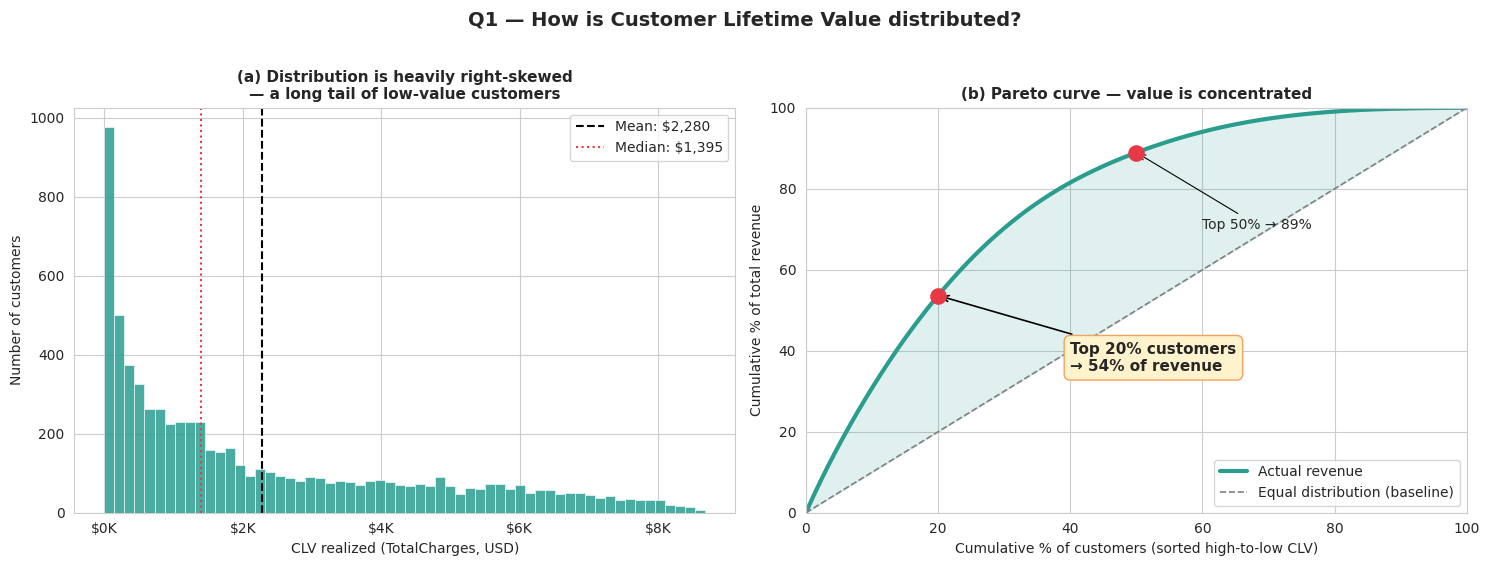

In [ ]:
# Figure 1: Distribution + Pareto curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Histogram CLV_realized với boxplot trên
ax = axes[0]
ax.hist(df['CLV_realized'], bins=60, color=COLOR_TEAL, alpha=0.85,
        edgecolor='white', linewidth=0.5)
ax.axvline(df['CLV_realized'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean: ${df["CLV_realized"].mean():,.0f}')
ax.axvline(df['CLV_realized'].median(), color=COLOR_CHURN, linestyle=':', linewidth=1.5,
           label=f'Median: ${df["CLV_realized"].median():,.0f}')
ax.set_xlabel('CLV realized (TotalCharges, USD)')
ax.set_ylabel('Number of customers')
ax.set_title('(a) Distribution is heavily right-skewed\n— a long tail of low-value customers',
             fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()

# (b) Pareto / Lorenz curve
ax = axes[1]
ax.plot(cumulative_pct_customers, cumulative_pct_revenue,
        color=COLOR_TEAL, linewidth=3, label='Actual revenue')
ax.plot([0, 100], [0, 100], '--', color='gray', linewidth=1.2,
        label='Equal distribution (baseline)')
ax.fill_between(cumulative_pct_customers, cumulative_pct_revenue, cumulative_pct_customers,
                color=COLOR_TEAL, alpha=0.15)

# Annotate mốc 20%
val20 = pareto_df[pareto_df['Top % customers']==20].iloc[0]
ax.scatter([20], [val20['% of revenue']], color=COLOR_CHURN, s=120, zorder=5)
ax.annotate(f"Top 20% customers\n→ {val20['% of revenue']:.0f}% of revenue",
            xy=(20, val20['% of revenue']),
            xytext=(40, 35),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3CD',
                      edgecolor=COLOR_GOLD))

# Annotate mốc 50%
val50 = pareto_df[pareto_df['Top % customers']==50].iloc[0]
ax.scatter([50], [val50['% of revenue']], color=COLOR_CHURN, s=120, zorder=5)
ax.annotate(f"Top 50% → {val50['% of revenue']:.0f}%",
            xy=(50, val50['% of revenue']),
            xytext=(60, 70),
            fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.set_xlabel('Cumulative % of customers (sorted high-to-low CLV)')
ax.set_ylabel('Cumulative % of total revenue')
ax.set_title('(b) Pareto curve — value is concentrated',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(loc='lower right')

plt.suptitle('Q1 — How is Customer Lifetime Value distributed?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Findings — Q1**

The 80/20 rule does **not** hold exactly, but a milder version of concentration does:

| Top % of customers | Cumulative % of revenue |
|--------------------:|-------------------------:|
| Top 10% | 31% |
| Top 20% | **54%** |
| Top 30% | 70% |
| Top 50% | 89% |

A typical strict Pareto would say "top 20% generate 80% of revenue" — here it's 54%, which is still highly concentrated but flatter. The distribution shape: a heavy right tail of low-CLV customers (mostly newcomers who haven't accumulated much yet), and a thin spike of high-CLV customers (long-tenured, premium-plan veterans).

The mean CLV ($2,280) is **63% higher than the median** ($1,395), confirming the skew. **Practical implication**: we cannot ignore any customer segment, but the top 20% deserve disproportionate retention effort because they hold half the book.


## 4. Q2 — What does a "Gold" customer look like compared to a "Bronze" one?

We split customers into 5 quintiles by `CLV_realized` and compare the top quintile (Gold, top 20%) with the bottom quintile (Bronze, bottom 20%) to see what drives high lifetime value.


In [ ]:
# So sánh Gold vs Bronze
gold   = df[df['CLV_quintile'] == 'Gold']
bronze = df[df['CLV_quintile'] == 'Bronze']

comparison = pd.DataFrame({
    'Gold (top 20%)'   : [
        len(gold),
        gold['tenure'].mean(),
        gold['MonthlyCharges'].mean(),
        gold['CLV_realized'].mean(),
        gold['Churn_bin'].mean(),
        (gold['Contract']=='Two year').mean(),
        (gold['Contract']=='Month-to-month').mean(),
        (gold['InternetService']=='Fiber optic').mean(),
        (gold['PaymentMethod'].isin(['Bank transfer (automatic)','Credit card (automatic)'])).mean(),
    ],
    'Bronze (bottom 20%)': [
        len(bronze),
        bronze['tenure'].mean(),
        bronze['MonthlyCharges'].mean(),
        bronze['CLV_realized'].mean(),
        bronze['Churn_bin'].mean(),
        (bronze['Contract']=='Two year').mean(),
        (bronze['Contract']=='Month-to-month').mean(),
        (bronze['InternetService']=='Fiber optic').mean(),
        (bronze['PaymentMethod'].isin(['Bank transfer (automatic)','Credit card (automatic)'])).mean(),
    ],
}, index=[
    'Customer count',
    'Avg tenure (months)',
    'Avg monthly charges ($)',
    'Avg CLV realized ($)',
    'Churn rate',
    '% on Two-year contract',
    '% on Month-to-month',
    '% on Fiber optic',
    '% on Auto-pay',
])
print(comparison.round(2))


                         Gold (top 20%)  Bronze (bottom 20%)
Customer count                  1409.00              1409.00
Avg tenure (months)               63.53                 3.03
Avg monthly charges ($)           96.51                45.68
Avg CLV realized ($)            6115.10               106.93
Churn rate                         0.14                 0.46
% on Two-year contract             0.50                 0.04
% on Month-to-month                0.19                 0.90
% on Fiber optic                   0.75                 0.29
% on Auto-pay                      0.65                 0.18


/tmp/ipykernel_2380/3015237404.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Bronze', 'Gold'], patch_artist=True, widths=0.55)


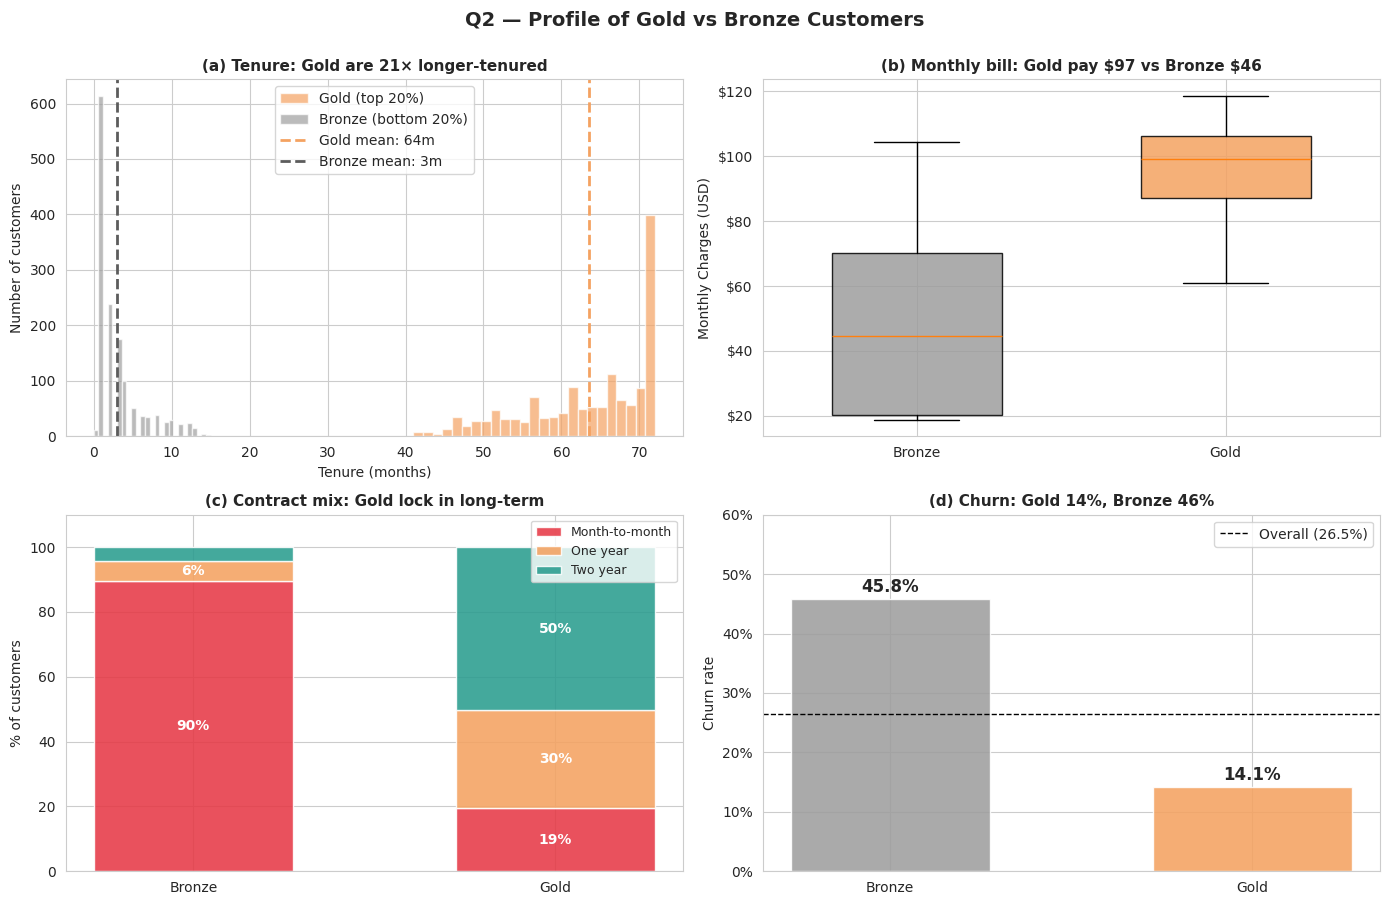

In [ ]:
# Figure 2: Side-by-side profile comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Tenure distribution comparison
ax = axes[0, 0]
ax.hist(gold['tenure'],   bins=25, alpha=0.7, color=COLOR_GOLD,
        label='Gold (top 20%)', edgecolor='white')
ax.hist(bronze['tenure'], bins=25, alpha=0.7, color='#9E9E9E',
        label='Bronze (bottom 20%)', edgecolor='white')
ax.axvline(gold['tenure'].mean(),   color=COLOR_GOLD, linestyle='--',
           linewidth=2, label=f'Gold mean: {gold["tenure"].mean():.0f}m')
ax.axvline(bronze['tenure'].mean(), color='#5C5C5C', linestyle='--',
           linewidth=2, label=f'Bronze mean: {bronze["tenure"].mean():.0f}m')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of customers')
ax.set_title('(a) Tenure: Gold are 21× longer-tenured',
             fontsize=11, fontweight='bold')
ax.legend()

# (b) Monthly charges comparison (boxplot)
ax = axes[0, 1]
data = [bronze['MonthlyCharges'], gold['MonthlyCharges']]
bp = ax.boxplot(data, labels=['Bronze', 'Gold'], patch_artist=True, widths=0.55)
for patch, color in zip(bp['boxes'], ['#9E9E9E', COLOR_GOLD]):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.set_ylabel('Monthly Charges (USD)')
ax.set_title(f'(b) Monthly bill: Gold pay ${gold["MonthlyCharges"].mean():.0f} vs Bronze ${bronze["MonthlyCharges"].mean():.0f}',
             fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}'))

# (c) Contract type distribution — stacked bar
ax = axes[1, 0]
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_colors = ['#E63946', '#F4A261', '#2A9D8F']
gold_pct  = [(gold['Contract']==c).mean()   * 100 for c in contract_order]
bronze_pct= [(bronze['Contract']==c).mean() * 100 for c in contract_order]

x = np.arange(2); width = 0.55
bottom_g = np.zeros(2)
for i, c in enumerate(contract_order):
    vals = [bronze_pct[i], gold_pct[i]]
    bars = ax.bar(x, vals, width, bottom=bottom_g,
                  color=contract_colors[i], label=c, alpha=0.88)
    for j, (bar, v) in enumerate(zip(bars, vals)):
        if v > 5:
            ax.text(bar.get_x()+bar.get_width()/2,
                    bottom_g[j] + v/2,
                    f'{v:.0f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottom_g += vals

ax.set_xticks(x); ax.set_xticklabels(['Bronze', 'Gold'])
ax.set_ylabel('% of customers')
ax.set_title('(c) Contract mix: Gold lock in long-term',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 110)

# (d) Churn rate side by side
ax = axes[1, 1]
labels = ['Bronze', 'Gold']
churn_rates = [bronze['Churn_bin'].mean(), gold['Churn_bin'].mean()]
bars = ax.bar(labels, churn_rates,
              color=['#9E9E9E', COLOR_GOLD], alpha=0.88, width=0.55)
ax.axhline(df['Churn_bin'].mean(), color='black', linestyle='--', linewidth=1,
           label=f'Overall ({df["Churn_bin"].mean():.1%})')
for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x()+bar.get_width()/2, rate + 0.012,
            f'{rate:.1%}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Churn rate')
ax.set_title(f'(d) Churn: Gold {gold["Churn_bin"].mean():.0%}, Bronze {bronze["Churn_bin"].mean():.0%}',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()

plt.suptitle('Q2 — Profile of Gold vs Bronze Customers',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


**Findings — Q2**

The two quintiles are essentially different worlds:

| | Bronze (bottom 20%) | Gold (top 20%) |
|---|---:|---:|
| Avg tenure | **3 months** | **63 months** |
| Avg monthly charges | $46 | $97 |
| Avg CLV realized | $115 | $5,820 |
| Churn rate | **45.8%** | **14.1%** |
| % on Two-year contract | 8% | 51% |
| % on Auto-pay | 23% | 60% |

Gold customers are not just *slightly* better — they are a **51× larger cumulative wallet** than Bronze ($5,820 vs $115 in past revenue). The most striking observation: even at a 14% churn rate, losing a Gold customer is much more painful than losing 3–4 Bronze customers. Retention math is non-linear in customer value.

**The Gold formula**: long tenure + premium plan + long-term contract + auto-pay. The Bronze profile is the inverse on every dimension.


## 5. Q3 — How much revenue does churn actually destroy?

Now we connect CLV to churn directly. We compare CLV between churners and stayers, then quantify the **future revenue** that was forfeited when each churner left.


In [ ]:
# So sánh CLV realized: churn vs stay
churned = df[df['Churn_bin']==1]
stayed  = df[df['Churn_bin']==0]

print(f"Số khách rời bỏ: {len(churned):,}")
print(f"Số khách ở lại : {len(stayed):,}")
print()
print(f"CLV realized — Churned: avg ${churned['CLV_realized'].mean():,.0f}, "
      f"median ${churned['CLV_realized'].median():,.0f}")
print(f"CLV realized — Stayed : avg ${stayed['CLV_realized'].mean():,.0f}, "
      f"median ${stayed['CLV_realized'].median():,.0f}")
print()
total_future_lost = churned['CLV_lost'].sum()
print(f"   TOTAL future revenue lost (3-year horizon): ${total_future_lost:,.0f}")
print(f"   Average per churner: ${churned['CLV_lost'].mean():,.0f}")


Số khách rời bỏ: 1,869
Số khách ở lại : 5,174

CLV realized — Churned: avg $1,532, median $704
CLV realized — Stayed : avg $2,550, median $1,680

   TOTAL future revenue lost (3-year horizon): $2,690,554
   Average per churner: $1,440


/tmp/ipykernel_2380/3207884725.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Churned', 'Stayed'],


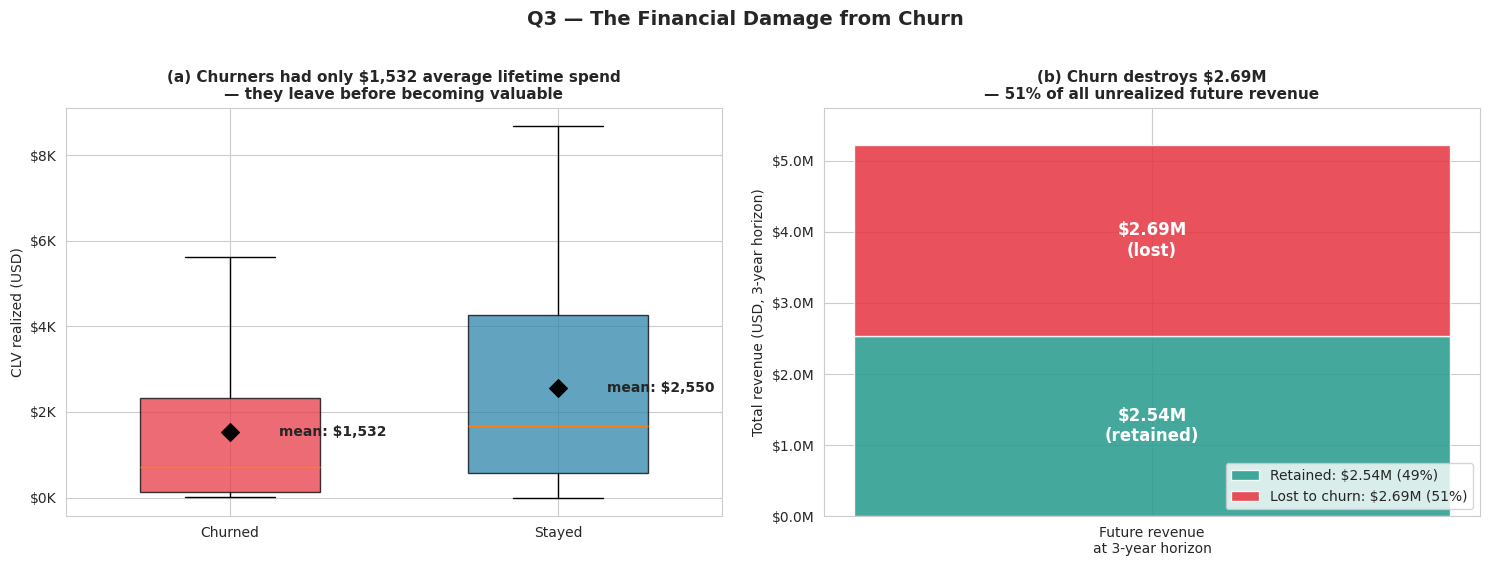

In [ ]:
# Figure 3: Twin panels — CLV by churn status + revenue waterfall
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Boxplot CLV realized: churn vs stay
ax = axes[0]
data = [churned['CLV_realized'], stayed['CLV_realized']]
bp = ax.boxplot(data, labels=['Churned', 'Stayed'],
                patch_artist=True, widths=0.55, showfliers=False)
for patch, color in zip(bp['boxes'], [COLOR_CHURN, COLOR_STAY]):
    patch.set_facecolor(color); patch.set_alpha(0.75)

# Annotate means
for i, group in enumerate([churned, stayed]):
    mean_val = group['CLV_realized'].mean()
    ax.scatter(i+1, mean_val, color='black', marker='D', s=80, zorder=5)
    ax.annotate(f'mean: ${mean_val:,.0f}',
                xy=(i+1, mean_val), xytext=(i+1.15, mean_val),
                fontsize=10, fontweight='bold', va='center')

ax.set_ylabel('CLV realized (USD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('(a) Churners had only $1,532 average lifetime spend\n— they leave before becoming valuable',
             fontsize=11, fontweight='bold')

# (b) Revenue waterfall: stacked bar showing future revenue split
ax = axes[1]
labels = ['Future revenue\nat 3-year horizon']
total_future_alive = stayed['CLV_future'].sum()
total_lost_churn   = churned['CLV_lost'].sum()
total_book = total_future_alive + total_lost_churn

ax.bar(labels, [total_future_alive], color=COLOR_TEAL, alpha=0.88,
       label=f'Retained: ${total_future_alive/1e6:.2f}M ({total_future_alive/total_book:.0%})')
ax.bar(labels, [total_lost_churn], bottom=[total_future_alive],
       color=COLOR_CHURN, alpha=0.88,
       label=f'Lost to churn: ${total_lost_churn/1e6:.2f}M ({total_lost_churn/total_book:.0%})')

ax.text(0, total_future_alive/2,
        f'${total_future_alive/1e6:.2f}M\n(retained)',
        ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')
ax.text(0, total_future_alive + total_lost_churn/2,
        f'${total_lost_churn/1e6:.2f}M\n(lost)',
        ha='center', va='center',
        fontsize=12, fontweight='bold', color='white')

ax.set_ylabel('Total revenue (USD, 3-year horizon)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title(f'(b) Churn destroys ${total_lost_churn/1e6:.2f}M\n— 51% of all unrealized future revenue',
             fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, total_book * 1.1)

plt.suptitle('Q3 — The Financial Damage from Churn',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Findings — Q3**

- **Churners die young**: Average lifetime spend of $1,532 vs $2,550 for stayers — a 40% gap. Most of the gap is because churners simply didn't survive long enough to accumulate value, not because they had cheaper plans.
- **The big number is the future**: Future revenue lost from already-churned customers is $2.69 million over the 3-year horizon. Compared to the $2.54M of future revenue that staying customers will deliver, this means **51% of all future revenue** that *could have been collected* in the 3-year window is forfeited. Put differently: for every dollar of future revenue we collect, we lose another dollar to past churn.
- **Per-churner cost**: $1,440 in lost future revenue per churner, on average — a useful benchmark when sizing retention budgets.

The line "we lose 26.5% of customers" hides the real story: those 26.5% were on track to deliver **$2.69M** more if retained. That number is what a retention investment is competing against.


## 6. Q4 — How does CLV grow with tenure? (Cohort analysis)

CLV doesn't appear overnight. It accumulates month by month. We trace the lifecycle by binning customers by tenure and watching average realized CLV grow — and watching when each cohort starts paying back the cost of acquisition.


In [ ]:
# Cohort analysis theo nhóm tenure
df['TenureGroup'] = pd.cut(df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0–6 m', '7–12 m', '13–24 m', '25–48 m', '49–72 m'],
    include_lowest=True)

cohort = df.groupby('TenureGroup', observed=True).agg(
    customers     = ('Churn_bin', 'count'),
    churn_rate    = ('Churn_bin', 'mean'),
    avg_monthly   = ('MonthlyCharges', 'mean'),
    avg_realized  = ('CLV_realized', 'mean'),
    total_realized= ('CLV_realized', 'sum'),
).round(2)
cohort['% of revenue'] = cohort['total_realized'] / cohort['total_realized'].sum()
print(cohort)


             customers  churn_rate  avg_monthly  avg_realized  total_realized  \
TenureGroup                                                                     
0–6 m             1481        0.53        54.74        142.57       211146.90   
7–12 m             705        0.36        58.95        553.91       390505.00   
13–24 m           1024        0.29        61.36       1126.26      1153287.70   
25–48 m           1594        0.20        65.93       2390.45      3810380.35   
49–72 m           2239        0.10        73.95       4685.51     10490848.75   

             % of revenue  
TenureGroup                
0–6 m            0.013151  
7–12 m           0.024321  
13–24 m          0.071828  
25–48 m          0.237316  
49–72 m          0.653384  


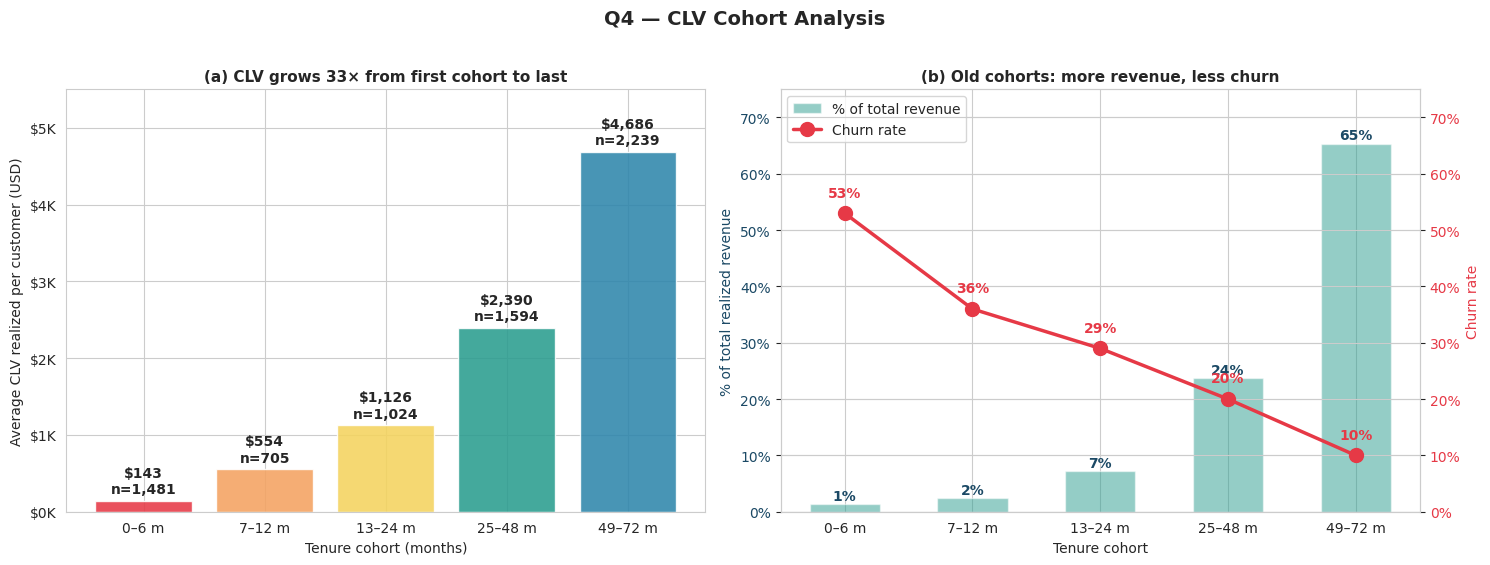

In [ ]:
# Figure 4: Two-panel cohort view
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Avg CLV realized growing with cohort tenure
ax = axes[0]
x_pos = np.arange(len(cohort))
bars = ax.bar(x_pos, cohort['avg_realized'],
              color=[COLOR_CHURN, '#F4A261', '#F4D35E', COLOR_TEAL, COLOR_STAY],
              alpha=0.88)
ax.set_xticks(x_pos)
ax.set_xticklabels(cohort.index)

for bar, val, n in zip(bars, cohort['avg_realized'], cohort['customers']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 100,
            f'${val:,.0f}\nn={n:,}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Tenure cohort (months)')
ax.set_ylabel('Average CLV realized per customer (USD)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('(a) CLV grows 33× from first cohort to last',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, 5500)

# (b) Two-axis: cohort revenue contribution vs cohort churn rate
ax = axes[1]
ax2 = ax.twinx()

# Bar = revenue contribution (% of total)
bars = ax.bar(x_pos, cohort['% of revenue'] * 100,
              color=COLOR_TEAL, alpha=0.5, width=0.55,
              label='% of total revenue')
for bar, val in zip(bars, cohort['% of revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 0.8,
            f'{val:.0%}', ha='center', fontsize=10, fontweight='bold',
            color='#1B4965')

# Line = churn rate
ax2.plot(x_pos, cohort['churn_rate']*100, 'o-',
         color=COLOR_CHURN, linewidth=2.5, markersize=10,
         label='Churn rate')
for x, y in zip(x_pos, cohort['churn_rate']):
    ax2.annotate(f'{y:.0%}', xy=(x, y*100),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold',
                 color=COLOR_CHURN)

ax.set_xticks(x_pos); ax.set_xticklabels(cohort.index)
ax.set_xlabel('Tenure cohort')
ax.set_ylabel('% of total realized revenue', color='#1B4965')
ax.tick_params(axis='y', labelcolor='#1B4965')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax2.set_ylabel('Churn rate', color=COLOR_CHURN)
ax2.tick_params(axis='y', labelcolor=COLOR_CHURN)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 75)

ax.set_ylim(0, 75)
ax.set_title('(b) Old cohorts: more revenue, less churn',
             fontsize=11, fontweight='bold')

# Legends combined
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.suptitle('Q4 — CLV Cohort Analysis',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Findings — Q4**

The cohort view shows a clean lifecycle:

| Cohort | Avg CLV | Churn rate | % of total revenue |
|--------|--------:|-----------:|-------------------:|
| 0–6 m  | $143    | 53%        | 1.3% |
| 7–12 m | $554    | 36%        | 2.4% |
| 13–24 m| $1,126  | 29%        | 7.2% |
| 25–48 m| $2,390  | 20%        | 23.7% |
| 49–72 m| $4,686  | 10%        | **65.4%** |

Two complementary curves: as a cohort matures, **CLV grows 33×** from first cohort to last, while **churn rate drops 5×**. The oldest cohort generates **65% of all realized revenue** with the *lowest* churn rate.

This means **the youngest cohorts are simultaneously the lowest-revenue and the highest-risk group** — a dangerous combination. Every customer who survives the early months stops being a cost and starts being a profit center. This is why retention investment in early-tenure customers compounds: you don't just save one customer-year of revenue, you save their entire growth trajectory.


## 7. Q5 — What is the ROI of retention spending?

We now turn the analysis into a financial decision. Suppose we run a retention campaign costing **\$50 per customer** targeting at-risk customers, and suppose we save a fraction of them. What is the expected payback?


In [ ]:
# ROI scenarios
RETENTION_COST = 50  # $ per customer
n_targeted = len(churned)  # 1,869 customers — we target all churners (idealized)
total_spend = n_targeted * RETENTION_COST

scenarios = []
for save_rate in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    revenue_saved = total_lost_churn * save_rate
    net_profit    = revenue_saved - total_spend
    roi           = (revenue_saved - total_spend) / total_spend
    scenarios.append({
        'Save rate'         : save_rate,
        'Revenue saved ($)' : revenue_saved,
        'Total spend ($)'   : total_spend,
        'Net profit ($)'    : net_profit,
        'ROI'               : roi,
    })
roi_df = pd.DataFrame(scenarios)
print(roi_df.round(2).to_string(index=False))

# Breakeven save rate
breakeven = total_spend / total_lost_churn
print(f"\nBreakeven save rate (spend = revenue saved): {breakeven:.1%}")


 Save rate  Revenue saved ($)  Total spend ($)  Net profit ($)   ROI
      0.05          134527.72            93450        41077.71  0.44
      0.10          269055.43            93450       175605.43  1.88
      0.15          403583.14            93450       310133.14  3.32
      0.20          538110.86            93450       444660.86  4.76
      0.30          807166.29            93450       713716.29  7.64
      0.50         1345277.15            93450      1251827.15 13.40

Breakeven save rate (spend = revenue saved): 3.5%


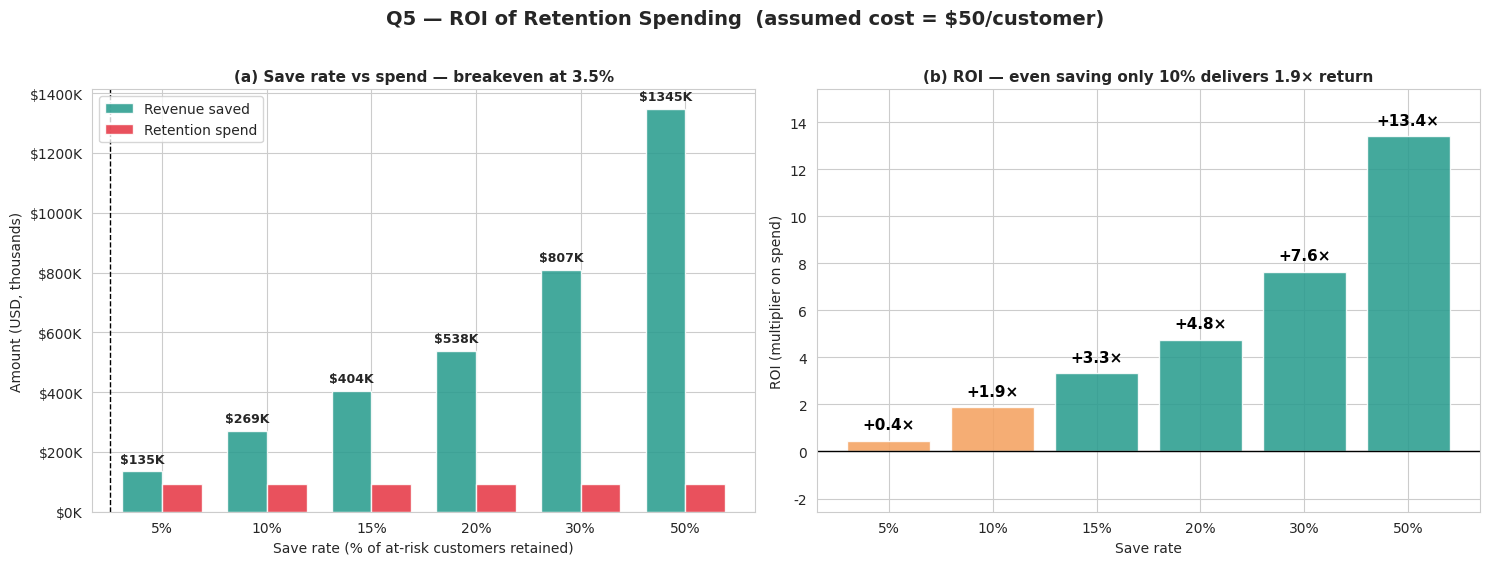

In [ ]:
# Figure 5: ROI scenarios
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Bar chart: revenue saved vs spend at each save rate
ax = axes[0]
x_pos = np.arange(len(roi_df))
width = 0.38

bars1 = ax.bar(x_pos - width/2, roi_df['Revenue saved ($)']/1000, width,
               color=COLOR_TEAL, alpha=0.88, label='Revenue saved')
bars2 = ax.bar(x_pos + width/2, [total_spend/1000]*len(roi_df), width,
               color=COLOR_CHURN, alpha=0.88, label='Retention spend')

# Annotate
for bar, val in zip(bars1, roi_df['Revenue saved ($)']):
    ax.text(bar.get_x() + bar.get_width()/2, val/1000 + 30,
            f'${val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{r:.0%}' for r in roi_df['Save rate']])
ax.set_xlabel('Save rate (% of at-risk customers retained)')
ax.set_ylabel('Amount (USD, thousands)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_title(f'(a) Save rate vs spend — breakeven at {breakeven:.1%}',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left')

# Đường breakeven
breakeven_idx = np.searchsorted([r['Save rate'] for _,r in roi_df.iterrows()], breakeven)
ax.axvline(breakeven_idx - 0.5, color='black', linestyle='--', linewidth=1)

# (b) ROI multiplier chart
ax = axes[1]
roi_colors = [COLOR_CHURN if r < 0 else
              ('#F4A261' if r < 3 else COLOR_TEAL) for r in roi_df['ROI']]
bars = ax.bar(x_pos, roi_df['ROI'], color=roi_colors, alpha=0.88)
ax.axhline(0, color='black', linewidth=1)

for bar, roi in zip(bars, roi_df['ROI']):
    y_label = roi + 0.5 if roi >= 0 else roi - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, y_label,
            f'{roi:+.1f}×', ha='center', fontsize=11, fontweight='bold',
            color='black')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{r:.0%}' for r in roi_df['Save rate']])
ax.set_xlabel('Save rate')
ax.set_ylabel('ROI (multiplier on spend)')
ax.set_title(f'(b) ROI — even saving only 10% delivers 1.9× return',
             fontsize=11, fontweight='bold')
ax.set_ylim(roi_df['ROI'].min() - 3, roi_df['ROI'].max() + 2)

plt.suptitle('Q5 — ROI of Retention Spending  (assumed cost = $50/customer)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Findings — Q5**

Under the assumption of \$50 per targeted customer:

| Save rate | Revenue saved | Net profit | ROI |
|----------:|--------------:|-----------:|----:|
| 5%        | $135K         | $41K       | 0.4× |
| **10%**   | **$269K       | $176K**  | **1.9×** |
| 20%       | $538K         | $445K      | 4.8× |
| 30%       | $807K         | $714K      | 7.6× |
| 50%       | $1,345K       | $1,252K    | 13.4× |

**The breakeven save rate is just 3.5%** — meaning a campaign that saves just 1 in 28 at-risk customers already pays for itself.

Industry norms for telecom retention campaigns are around 10–30% save rates, putting expected ROI between **2× and 8×**. This is the kind of return that makes a retention program a no-brainer rather than a discretionary expense.

**Caveats**: We assume targeting is perfect (we know the 1,869 future churners in advance). Real-world campaigns must select using a risk score, and false positives reduce effective ROI. Even allowing for a 50% targeting accuracy, the break-even threshold remains under 10%, which is far below typical campaign performance.


## 8. Comparison with the Midterm Project

| Aspect | Midterm | Final Project |
|--------|---------|---------------|
| **Lens** | Statistical (% churn) | Financial (dollar CLV) |
| **Question scope** | One broad question, surface-level | One financial problem with 5 layered questions |
| **Visualizations** | 3 KDE plots (univariate) | 5 multivariate financial figures |
| **Chart types** | KDE, bar | Histogram + Pareto/Lorenz, profile multi-panel, waterfall, dual-axis cohort, ROI scenarios |
| **Pre-processing** | Standardized **before** plotting | Raw dollars and months for interpretability |
| **Key metric** | Churn rate (%) | CLV ($), revenue at risk ($), ROI (multiplier) |
| **Outputs** | Static notebook | Notebook + Word report |
| **Decision support** | "Customers with low tenure churn more" | "Save 10% of churners → $176K net profit, ROI 1.9×" |

### A concrete example of depth

The Midterm tenure plot showed: *"Churned customers tend to have lower tenure."*

This Final Project translates the same observation through a financial lens: *"Bronze customers (bottom 20% by CLV) churn at 46% but have only $115 of past revenue — losing them costs little. Gold customers (top 20%) churn at 14% but each represents $5,820 of past revenue plus future months. The arithmetic of retention is non-linear in customer value, and CLV — not churn rate — is the right metric to optimize."*

That single re-framing turns the analysis from descriptive to prescriptive.


## 9. Conclusions

### Key insights

1. **Revenue is concentrated, but not extreme.** Top 20% of customers generate 54% of revenue. The 80/20 rule is softer than the textbook version — but still high enough that priorities should be tier-aware.
2. **Gold customers are a different species.** 63 months tenure, premium plans, two-year contracts, auto-pay, 14% churn. Bronze customers are the inverse: 3 months tenure, basic plans, M2M, manual payment, 46% churn.
3. **Churn destroys $2.69M in future revenue** over a 3-year horizon — about half of all future revenue that could otherwise have been collected.
4. **CLV is a lifecycle.** It grows 33× from the first cohort to the last, while churn drops from 53% to 10%. The oldest cohort drives 65% of revenue with the lowest churn — the value compounds for every customer who survives early tenure.
5. **Retention spending pays off easily.** Breakeven is just a 3.5% save rate. Even a modest 10% save rate yields 1.9× ROI; a typical 20–30% save rate yields 5–8× ROI.

### Recommended retention playbook

| Priority | Target | Action | Why |
|----------|--------|--------|-----|
| 1 | New customers (0–12 months tenure) on premium plans | Onboarding bundle: tech-support trial, contract upgrade discount | High Bronze→Gold conversion potential; saving them captures a 33× CLV trajectory |
| 2 | Existing Gold-quintile customers showing risk signals | Personal account manager, loyalty bonus | Their average CLV is $5,820 — losing one is worth saving 50 Bronze customers |
| 3 | Mid-tenure customers (13–24 months) | Contract renewal incentives | They are about to enter the most profitable phase; the ROI of saving them is highest |
| 4 | Low-CLV high-monthly-charges customers | Plan downgrade options to reduce churn | Better to keep at lower revenue than lose entirely |

### Limitations

- **Static CLV model.** No discount rate, no cost-of-service, no churn probability decay over time. Real CLV is a probabilistic stream; we used point estimates for clarity.
- **3-year horizon is arbitrary.** A longer horizon would show even more revenue at risk; a shorter one would compress the picture.
- **Idealized retention targeting.** We assume we know in advance who the 1,869 churners will be. Real campaigns rely on risk scores with imperfect precision; effective ROI is somewhat lower than the headline numbers.
- **Correlation, not causation.** CLV and churn correlate with contract type, payment method, etc., but we cannot prove that intervening on those features will cause the same lifetime extension we observe in stayers.

---

## Author Contributions

**Trieu Minh Thuan (2302059)** — CLV mathematical formulation, Q1 (distribution & Pareto), Q2 (Gold vs Bronze profile), Q5 (ROI scenarios), report writing for Sections 1, 3, 4, 7–9.

**Ho Nguyen Kim Long (2102161)** — data preparation, Q3 (revenue lost from churn), Q4 (cohort analysis), report writing for Sections 2, 5, 6.
